# **UNIT 1**

Load Library

In [209]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import os

Baca Dataset

In [210]:
BASE_DIR = os.getcwd()
UPLOAD_FOLDER = os.path.join(BASE_DIR, "static", "files")
LAST_FILE_PATH = os.path.join(BASE_DIR, "last_file.txt")
MODEL_SAVE_PATH = os.path.join(BASE_DIR, "model", "rf_model.joblib")
RESULT_SAVE_PATH = os.path.join(BASE_DIR, "data", "hasil_prediksi.csv")
CLEANED_SAVE_PATH = os.path.join(BASE_DIR, "data", "data_cleaned.csv")

In [211]:
def get_last_csv():
    print("Mengecek keberadaan file last_file.txt...")
    if not os.path.exists(LAST_FILE_PATH):
        raise FileNotFoundError("Belum ada data yang diupload.")
    
    with open(LAST_FILE_PATH, "r") as f:
        filename = f.read().strip()
    
    print(f"Nama file yang dibaca dari last_file.txt: {filename}")
    
    path = os.path.join(UPLOAD_FOLDER, filename)
    print(f"Mengecek apakah file {path} ada...")
    
    if not os.path.exists(path):
        raise FileNotFoundError(f"File terakhir '{filename}' tidak ditemukan di folder upload.")
    
    return path

In [212]:
csv_path = get_last_csv()
df = pd.read_csv(csv_path, sep=";", skipinitialspace=True, na_values="?", index_col='No')
df.head()


Mengecek keberadaan file last_file.txt...
Nama file yang dibaca dari last_file.txt: 260114_dbd_padangkotor.csv
Mengecek apakah file e:\Semester 7\Skripsi\Laporan Skripsi\Test Flask\static\files\260114_dbd_padangkotor.csv ada...


,Tahun,Bulan,ABJ,Jumlah Kasus
No,,,,
1,2017,Jan,NaN,40
2,2017,Feb,NaN,68
3,2017,Mar,NaN,61
4,2017,Apr,NaN,85
5,2017,Mei,NaN,35


In [213]:
df.describe()

,Tahun,Jumlah Kasus
count,96.000000,96.000000
mean,2020.500000,44.052083
std,2.303316,19.251996
min,2017.000000,9.000000
25%,2018.750000,30.000000
50%,2020.500000,43.000000
75%,2022.250000,56.250000
max,2024.000000,94.000000


# **UNIT 2**

MENGANALISIS TIPE DAN RELASI DATA

In [214]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96 entries, 1 to 96
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Tahun         96 non-null     int64 
 1   Bulan         96 non-null     object
 2   ABJ           53 non-null     object
 3   Jumlah Kasus  96 non-null     int64 
dtypes: int64(2), object(2)
memory usage: 3.8+ KB


BACA INFORMASI TERKAIT MISSING VALUE

In [215]:
#Hitung jumlah missing value per kolom
missing_values = df.isnull().sum()
print("\nJumlah misiing value per kolom:")
print(missing_values)


Jumlah misiing value per kolom:
Tahun            0
Bulan            0
ABJ             43
Jumlah Kasus     0
dtype: int64


MENGHITUNG PERSENTASE MISSUNG VALUE

In [216]:
#Hitung persentase misiing value
missing_percentage = (missing_values / len(df)) * 100
print("\nPersentase missing value per kolom")
print(missing_percentage)


Persentase missing value per kolom
Tahun            0.000000
Bulan            0.000000
ABJ             44.791667
Jumlah Kasus     0.000000
dtype: float64


1. ANALISIS STATISTIK DESKRIPTIF

STATISTIK DESKRIPTIF VARIABEL NUMERIK

In [217]:
#Statistik deskriptif untuk variabel numerik
df.describe()

,Tahun,Jumlah Kasus
count,96.000000,96.000000
mean,2020.500000,44.052083
std,2.303316,19.251996
min,2017.000000,9.000000
25%,2018.750000,30.000000
50%,2020.500000,43.000000
75%,2022.250000,56.250000
max,2024.000000,94.000000


STATISTIK VARIABEL KATEGORIKAL

In [218]:
#Statistik deskriptif untuk variabel kategorikal
df.describe(include=['object'])

,Bulan,ABJ
count,96,53
unique,12,52
top,Jan,"89,74"
freq,8,2


DISTRIBUSI TARGET VARIABEL

2.VISUALISASI DISTRIBUSI

VARIABELL NUMERIK MENGGUNAKAN HISTOGRAM

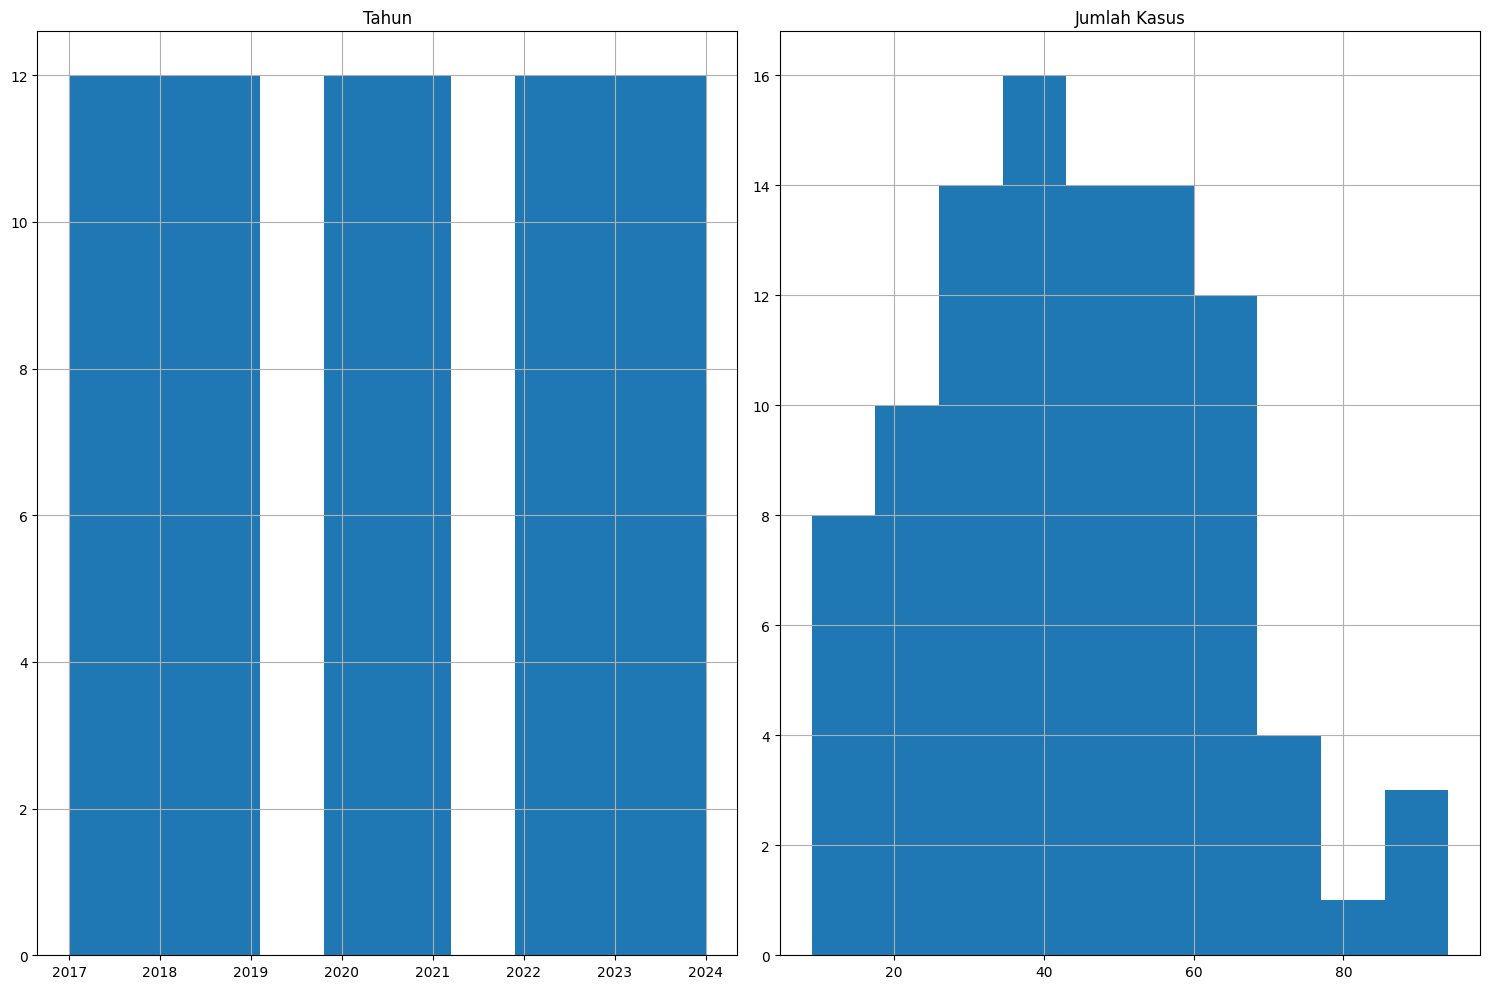

In [219]:
#Histogram untuk variabel numerik
numeric_features = df.select_dtypes(include=[np.number]).columns
df[numeric_features].hist(figsize=(15, 10))
plt.tight_layout()
plt.show()

VARIABEL KATEGORIKAL MENGGUNAKAN BAR PLOT

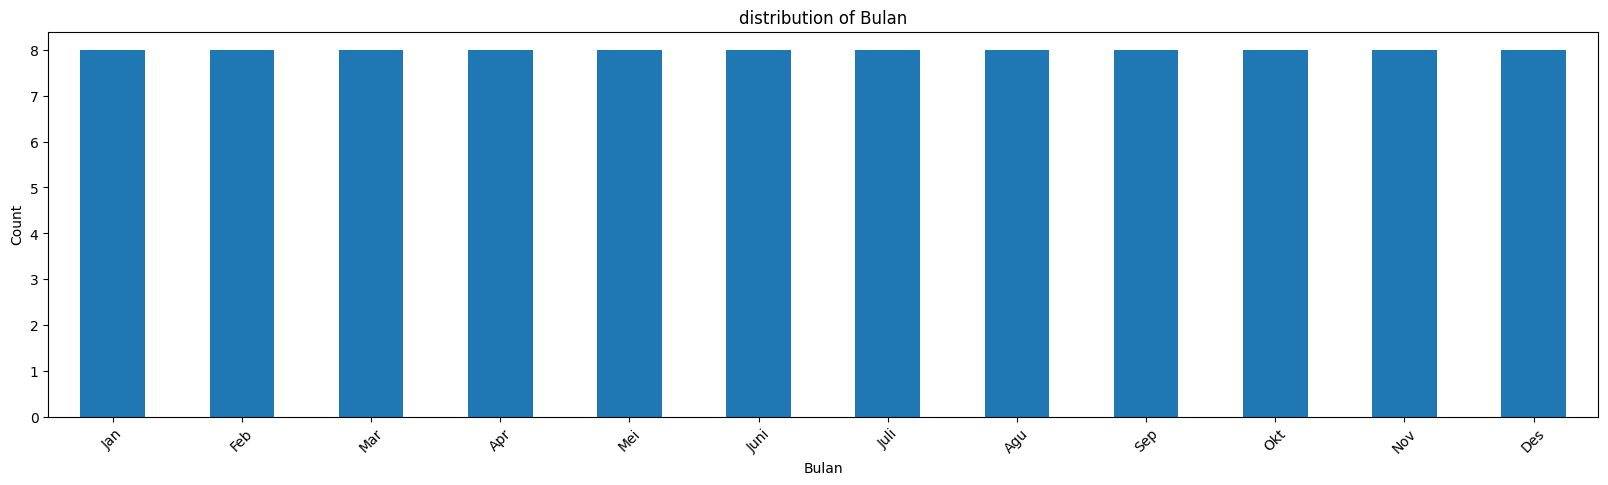

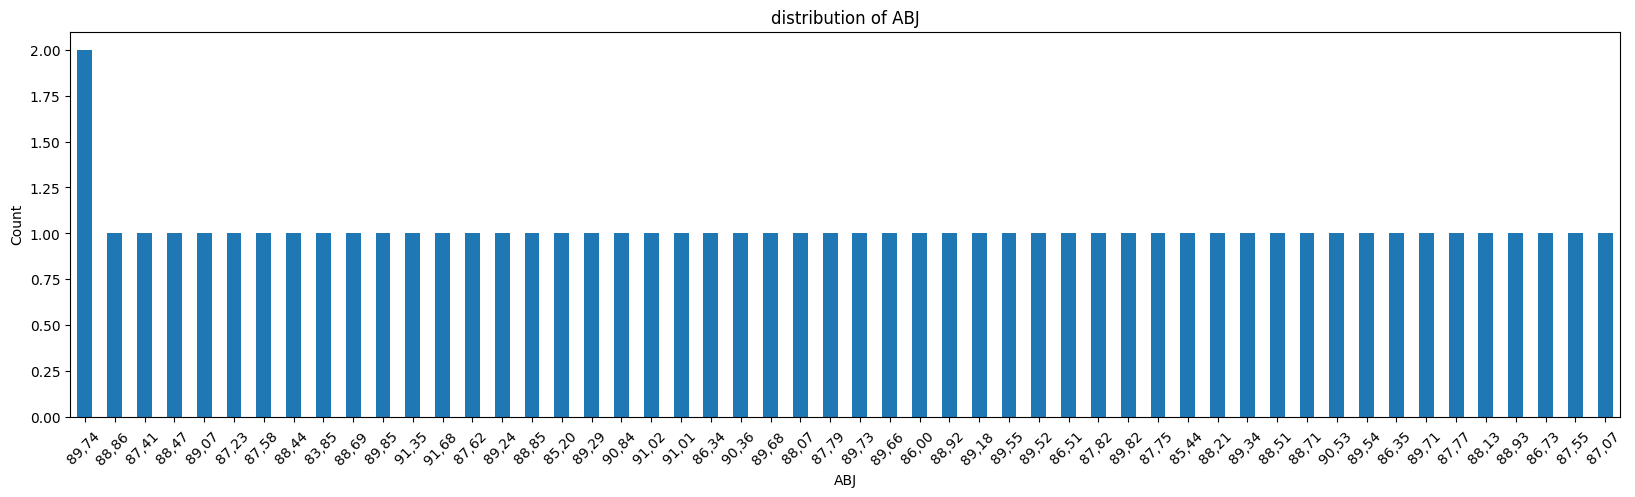

In [220]:
#Bar plot untuk variabel kategorikal
categorical_features = df.select_dtypes(include=['object']).columns
for feature in categorical_features:
    plt.figure(figsize=(20,5))
    df[feature].value_counts().plot(kind='bar')
    plt.title(f'distribution of {feature}')
    plt.ylabel('Count')
    plt.xlabel(feature)
    plt.xticks(rotation=45)
    plt.show()

3.ANALISA KORELASI

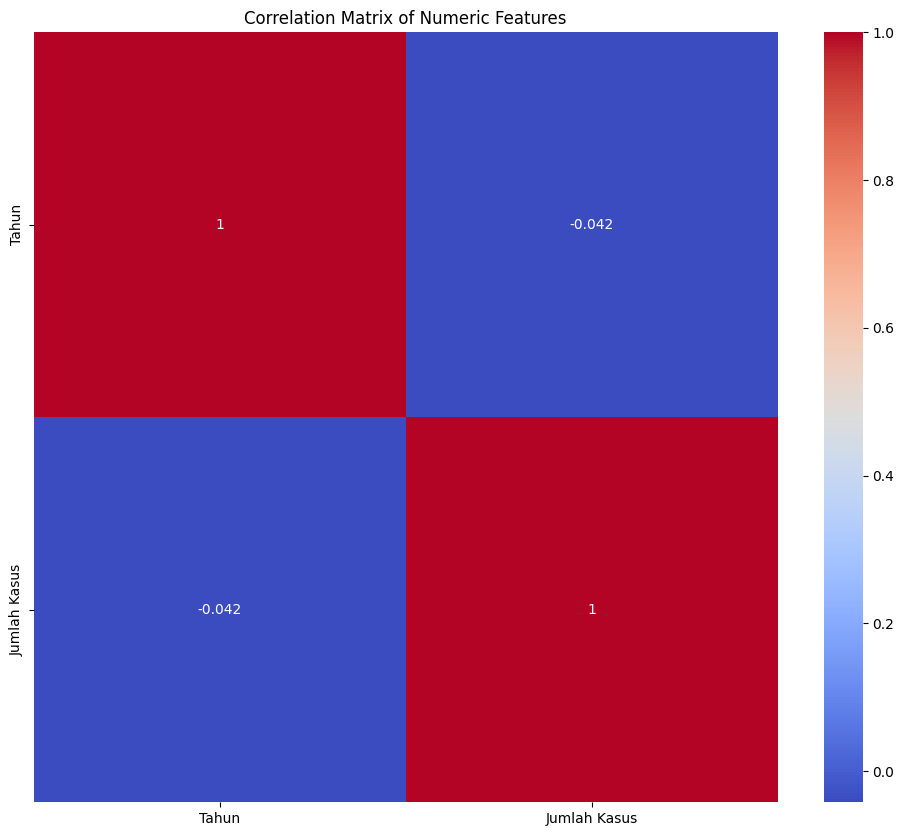

In [221]:
import seaborn as sns
#Korelasi antara variabel numerik
correlation_matrix = df[numeric_features].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Numeric Features')
plt.show()

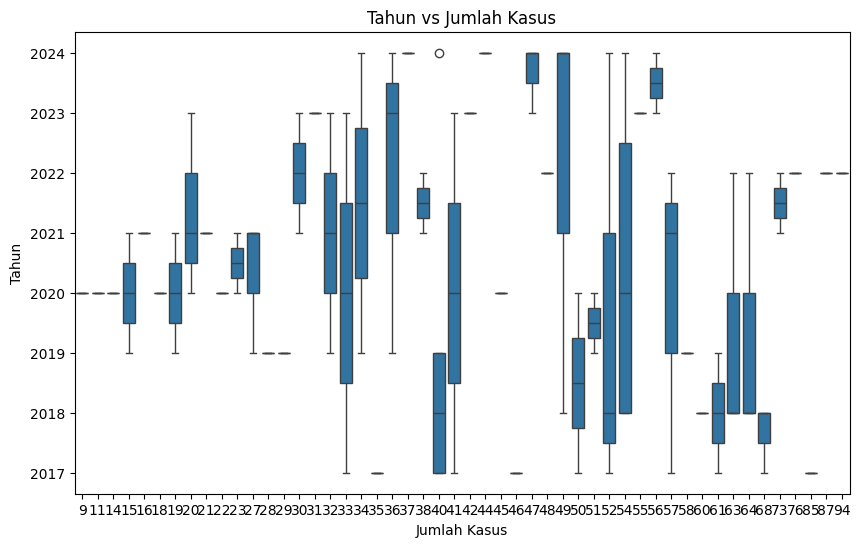

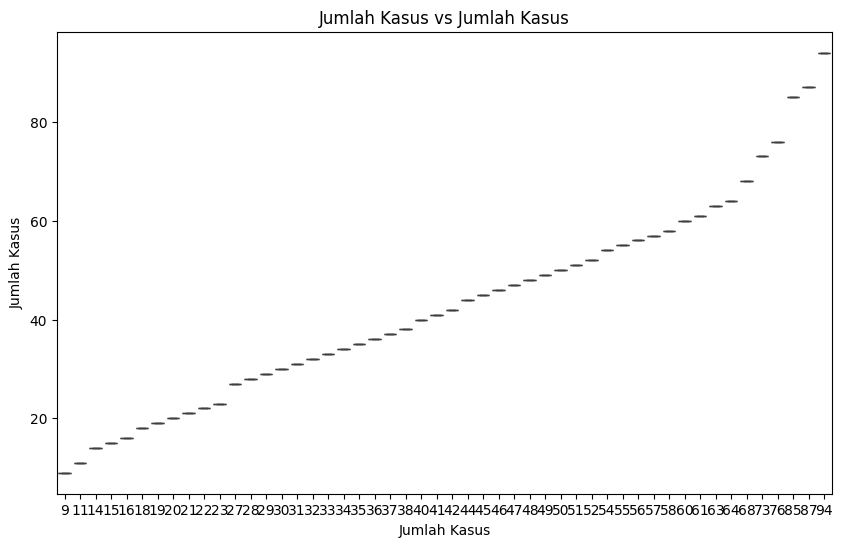

In [222]:
# Boxplt numerik vs target
for feature in numeric_features:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='Jumlah Kasus', y=feature, data=df)
    plt.title(f'{feature} vs Jumlah Kasus')
    plt.show()

<Figure size 1200x600 with 0 Axes>

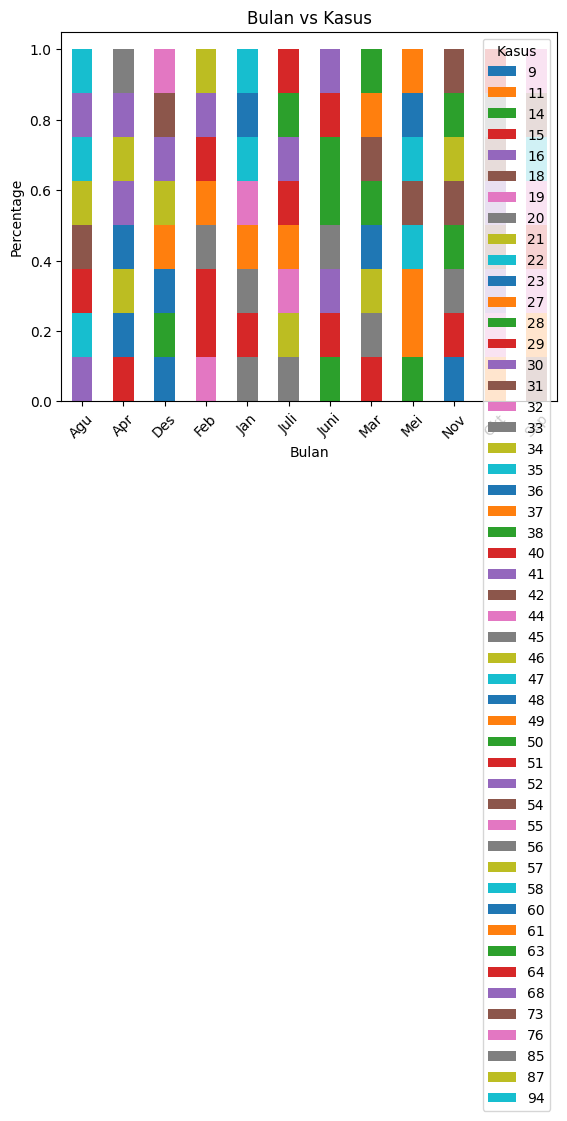

<Figure size 1200x600 with 0 Axes>

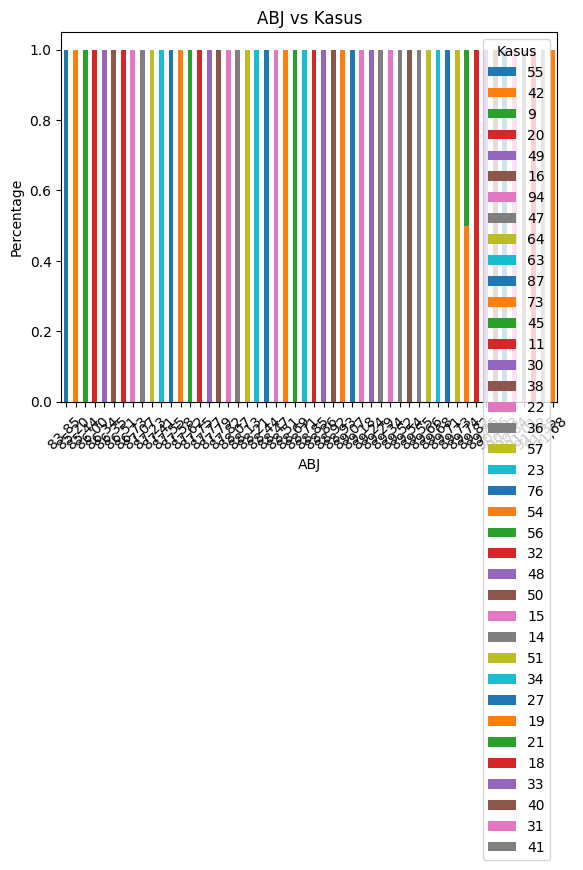

In [223]:
# Stacked bar plot kategorical vs target
for feature in categorical_features:
  if feature != 'Jumlah Kasus':
    plt.figure(figsize=(12, 6))
    df_temp = df.groupby([feature, 'Jumlah Kasus']).size().unstack()
    df_temp_perc = df_temp.div(df_temp.sum(axis=1), axis=0)
    df_temp_perc.plot(kind='bar', stacked=True)
    plt.title(f'{feature} vs Kasus')
    plt.xlabel(feature)
    plt.ylabel('Percentage')
    plt.legend(title='Kasus', loc='upper right')
    plt.xticks(rotation=45)
    plt.show()

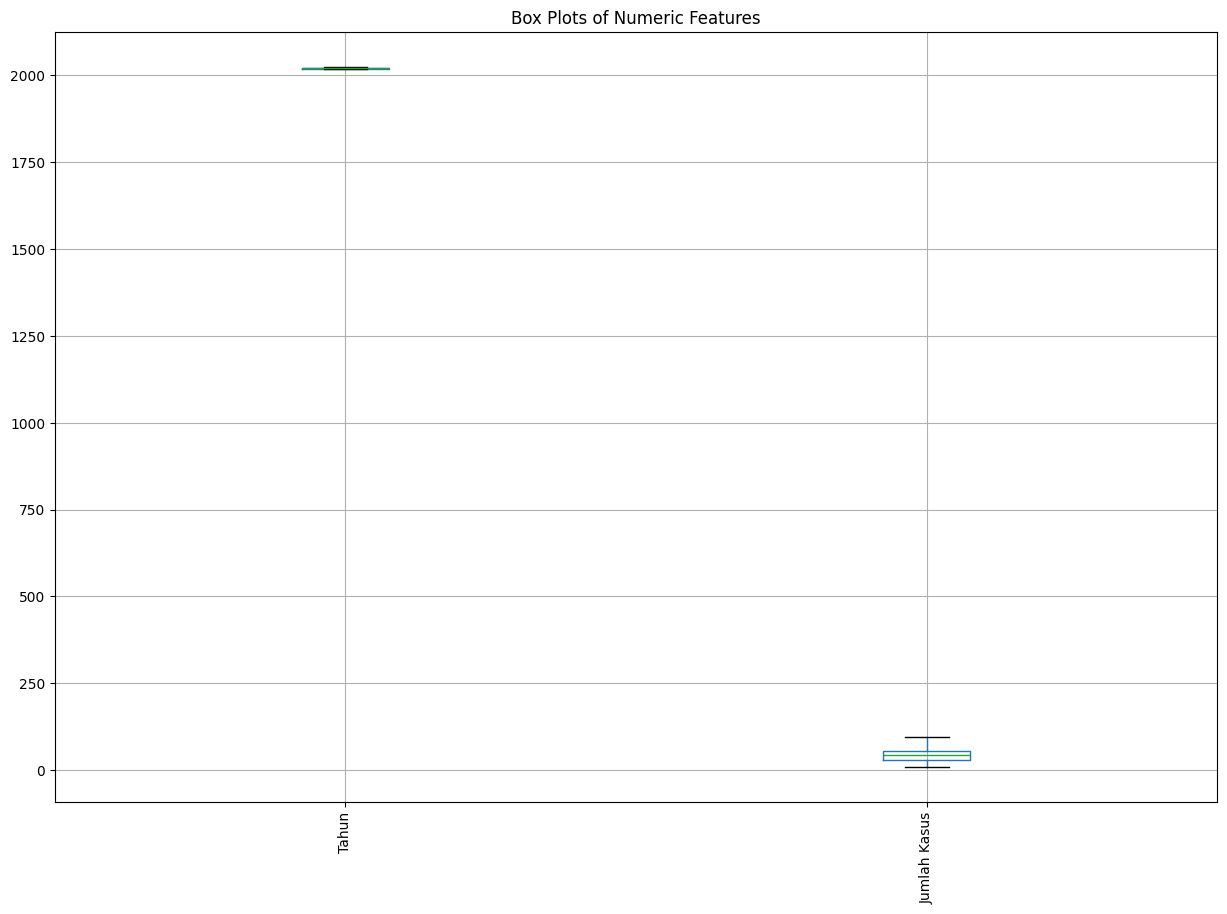

In [224]:
#iIdentifikasi Outlier
#Box plot untuk mendeteksi outlier pada variabel numerik
plt.figure(figsize=(15, 10))
df[numeric_features].boxplot()
plt.title('Box Plots of Numeric Features')
plt.xticks(rotation=90)
plt.show()

# **UNIT 3 MEMVALIDASI DATA**

# Periksa Missing Value

In [225]:
#Hitung jumlah missing values
missing_values = df.isnull().sum()

#Hitung persentase missing value
missing_percentage = 100 * df.isnull().sum() / len(df)

#Gabungkan informasi missing values
missing_table = pd.concat([missing_values, missing_percentage], axis=1, keys= ['Total', 'Percent'])

print(missing_table)

              Total    Percent
Tahun             0   0.000000
Bulan             0   0.000000
ABJ              43  44.791667
Jumlah Kasus      0   0.000000


# Visualisasi Missing Value

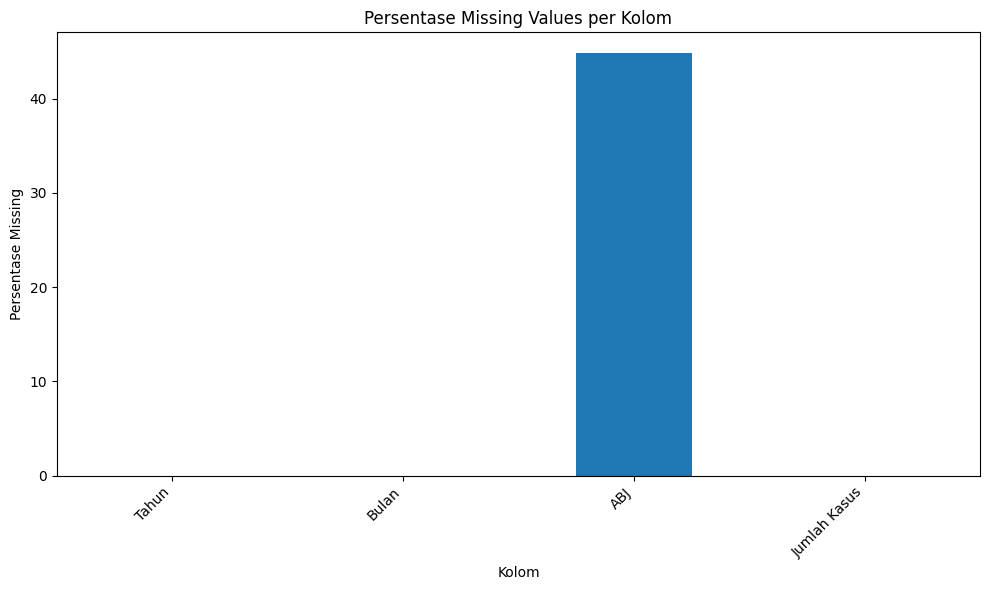

In [226]:
#Visualisasi Missing Value
plt.figure(figsize=(10, 6))
missing_percentage.plot(kind='bar')
plt.title('Persentase Missing Values per Kolom')
plt.xlabel('Kolom')
plt.ylabel('Persentase Missing')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Periksa Duplikat

In [227]:
#Hitung jumlah Duplikat
duplicates = df.duplicated().sum()
print(f"Jumlah baris duplikat: {duplicates}")

#Tampilkan beberapa baris duplikat (jika ada)
if duplicates > 0:
    print("\nContoh baris duplikat:")
    print(df[df.duplicated(keep=False)].head())

Jumlah baris duplikat: 0


# Validasi Tipe Data

In [228]:
#Tampilkan tipe data setiap kolom
print(df.dtypes)

#Periksa apakah ada nilai non-numerik dalam kolom numerik
numeric_columns = df.select_dtypes(include=[np.number]).columns
for col in numeric_columns:
    non_numeric = df[pd.to_numeric(df[col], errors='coerce').isna()]
    if len(non_numeric) > 0:
        print(f"\nNnilai non-numerik dalam kolom {col}:")
        print(non_numeric[col].unique())

Tahun            int64
Bulan           object
ABJ             object
Jumlah Kasus     int64
dtype: object


# Validasi Nilai Range

In [229]:
#periksa range nilai untuk kolom numerik
for col in numeric_columns:
  print(f"\n Range nilai untuk {col}:")
  print(f"Min: {df[col].min()}, Max: {df[col].max()}")


#periksa kategori unik untuk kolom kategorikal
categorical_columns = df.select_dtypes(include=['object']).columns
for col in categorical_columns:
  print(f"\nKategori unik dalam {col}:")
  print(df[col].unique())


 Range nilai untuk Tahun:
Min: 2017, Max: 2024

 Range nilai untuk Jumlah Kasus:
Min: 9, Max: 94

Kategori unik dalam Bulan:
['Jan' 'Feb' 'Mar' 'Apr' 'Mei' 'Juni' 'Juli' 'Agu' 'Sep' 'Okt' 'Nov' 'Des']

Kategori unik dalam ABJ:
[nan '87,62 ' '89,66 ' '88,92 ' '89,18 ' '89,55 ' '89,52 ' '86,51 '
 '87,82 ' '89,82 ' '87,75 ' '85,44 ' '88,21 ' '86,00 ' '89,74 ' '89,34 '
 '88,71 ' '90,53 ' '89,54 ' '86,35 ' '89,71 ' '87,77 ' '88,13 ' '88,93 '
 '86,73 ' '87,55 ' '88,51 ' '89,73 ' '88,86 ' '87,79 ' '87,41 ' '88,47 '
 '89,07 ' '87,23 ' '87,58 ' '88,44 ' '83,85 ' '88,69 ' '89,85 ' '91,35 '
 '91,68 ' '89,24 ' '88,85 ' '85,20 ' '89,29 ' '90,84 ' '91,02 ' '91,01 '
 '86,34 ' '90,36 ' '89,68 ' '88,07 ' '87,07 ']


# Periksa Konsistensi Data

# Visualisasi Konsistensi

UNIT 4

In [230]:
df.head()

,Tahun,Bulan,ABJ,Jumlah Kasus
No,,,,
1,2017,Jan,NaN,40
2,2017,Feb,NaN,68
3,2017,Mar,NaN,61
4,2017,Apr,NaN,85
5,2017,Mei,NaN,35


UNIT 5 MEMBERSIHKAN DATA

Menangani Missing Value

In [231]:
# Cek missing values sebelum pembersihan
print("Missing values sebelum pembersihan:")
print(df.isnull().sum())

# Konversi ABJ ke numerik (hapus koma & persen)
df['ABJ'] = (
    df['ABJ'].astype(str)
    .str.replace(',', '.', regex=False)
    .str.replace('%', '', regex=False)
)

df['ABJ'] = pd.to_numeric(df['ABJ'], errors='coerce')

# Imputasi MEAN per Bulan (lintas tahun)
df['ABJ'] = df.groupby('Bulan')['ABJ'].transform(
    lambda x: x.fillna(x.mean())
)

# Cadangan terakhir: MEAN global
df['ABJ'] = df['ABJ'].fillna(df['ABJ'].mean())

# Konversi dari persen ke desimal
df['ABJ'] = df['ABJ'] / 100
# Batasi 2 angka di belakang koma
df['ABJ'] = df['ABJ'].round(4)

# Cek ulang
print("Missing values setelah pembersihan:")
print(df.isnull().sum())

# Cek beberapa data
print(df[['Bulan', 'ABJ']].head())



Missing values sebelum pembersihan:
Tahun            0
Bulan            0
ABJ             43
Jumlah Kasus     0
dtype: int64
Missing values setelah pembersihan:
Tahun           0
Bulan           0
ABJ             0
Jumlah Kasus    0
dtype: int64
   Bulan     ABJ
No              
1    Jan  0.8611
2    Feb  0.8920
3    Mar  0.8926
4    Apr  0.8941
5    Mei  0.8954


In [232]:
Q1 = df['Jumlah Kasus'].quantile(0.25)
Q3 = df['Jumlah Kasus'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR

outliers = df[(df['Jumlah Kasus'] < lower_bound) | (df['Jumlah Kasus'] > upper_bound)]
print(outliers)


Empty DataFrame
Columns: [Tahun, Bulan, ABJ, Jumlah Kasus]
Index: []


In [233]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def handle_outlier(df):
    numeric_columns = df.select_dtypes(include=[np.number]).columns
    for col in numeric_columns:
        # plot sebelum handle
        plt.figure(figsize=(8,4))
        sns.boxplot(x=df[col])
        plt.title(f'Boxplot before handling outlier: {col}')
        plt.show()

        # IQR method
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # menangani outlier
        df[col] = np.where(df[col] > upper_bound, upper_bound,
                           np.where(df[col] < lower_bound, lower_bound, df[col]))

        # plot setelah handle
        plt.figure(figsize=(8,4))
        sns.boxplot(x=df[col])
        plt.title(f'Boxplot after handling outlier: {col}')
        plt.show()
    return df


In [234]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96 entries, 1 to 96
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Tahun         96 non-null     int64  
 1   Bulan         96 non-null     object 
 2   ABJ           96 non-null     float64
 3   Jumlah Kasus  96 non-null     int64  
dtypes: float64(1), int64(2), object(1)
memory usage: 3.8+ KB


In [235]:
df.head()

,Tahun,Bulan,ABJ,Jumlah Kasus
No,,,,
1,2017,Jan,0.8611,40
2,2017,Feb,0.8920,68
3,2017,Mar,0.8926,61
4,2017,Apr,0.8941,85
5,2017,Mei,0.8954,35


UNIT 6

Transformasi Data

In [236]:
#Periksa kategori unik untuk nilai kategorikal
categorical_columns = df.select_dtypes(include=['object']).columns
for col in categorical_columns:
  print(f"\nKategori unik dalam {col}:")
  print(df[col].unique())


Kategori unik dalam Bulan:
['Jan' 'Feb' 'Mar' 'Apr' 'Mei' 'Juni' 'Juli' 'Agu' 'Sep' 'Okt' 'Nov' 'Des']


In [237]:
Bulan = {'Jan':1, 'Feb':2, 'Mar':3, 'Apr':4, 'Mei':5, 'Juni':6, 'Juli':7, 'Agu':8, 'Sep':9, 'Okt':10, 'Nov':11, 'Des':12}
df['Bulan'] = df['Bulan'].map(Bulan)


In [238]:
# Pastikan data terurut agar shift() mengambil nilai dari bulan yang tepat di wilayah yang sama
df = df.sort_values(by=['Tahun', 'Bulan'])

# Membuat lag 1 bulan (jumlah kasus bulan lalu sebagai fitur untuk bulan ini)
df['Lag1'] = df['Jumlah Kasus'].shift(1)
df['Lag2'] = df['Jumlah Kasus'].shift(2)
df['Lag3'] = df['Jumlah Kasus'].shift(3)
df['Lag4'] = df['Jumlah Kasus'].shift(4)
df['Lag5'] = df['Jumlah Kasus'].shift(5)
df['Lag6'] = df['Jumlah Kasus'].shift(6)

df['Diff'] = df['Lag1'] - df['Lag2']

In [239]:
# 2. Hapus baris yang Jumlah Kasusnya kosong (NaN)
df = df.dropna()

In [240]:
df.head()

,Tahun,Bulan,ABJ,Jumlah Kasus,Lag1,Lag2,Lag3,Lag4,Lag5,Lag6,Diff
No,,,,,,,,,,,
7,2017,7,0.8813,52,33.0,35.0,85.0,61.0,68.0,40.0,-2.0
8,2017,8,0.8696,46,52.0,33.0,35.0,85.0,61.0,68.0,19.0
9,2017,9,0.8947,40,46.0,52.0,33.0,35.0,85.0,61.0,-6.0
10,2017,10,0.8840,41,40.0,46.0,52.0,33.0,35.0,85.0,-6.0
11,2017,11,0.8804,50,41.0,40.0,46.0,52.0,33.0,35.0,1.0


In [241]:
df

,Tahun,Bulan,ABJ,Jumlah Kasus,Lag1,Lag2,Lag3,Lag4,Lag5,Lag6,Diff
No,,,,,,,,,,,
7,2017,7,0.8813,52,33.0,35.0,85.0,61.0,68.0,40.0,-2.0
8,2017,8,0.8696,46,52.0,33.0,35.0,85.0,61.0,68.0,19.0
9,2017,9,0.8947,40,46.0,52.0,33.0,35.0,85.0,61.0,-6.0
10,2017,10,0.8840,41,40.0,46.0,52.0,33.0,35.0,85.0,-6.0
11,2017,11,0.8804,50,41.0,40.0,46.0,52.0,33.0,35.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...
92,2024,8,0.8696,47,49.0,52.0,47.0,36.0,34.0,40.0,-3.0
93,2024,9,0.8947,44,47.0,49.0,52.0,47.0,36.0,34.0,-2.0
94,2024,10,0.8840,56,44.0,47.0,49.0,52.0,47.0,36.0,-3.0


UBAH MENJADI NUMERIK

In [242]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 90 entries, 7 to 96
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Tahun         90 non-null     int64  
 1   Bulan         90 non-null     int64  
 2   ABJ           90 non-null     float64
 3   Jumlah Kasus  90 non-null     int64  
 4   Lag1          90 non-null     float64
 5   Lag2          90 non-null     float64
 6   Lag3          90 non-null     float64
 7   Lag4          90 non-null     float64
 8   Lag5          90 non-null     float64
 9   Lag6          90 non-null     float64
 10  Diff          90 non-null     float64
dtypes: float64(8), int64(3)
memory usage: 8.4 KB


In [243]:
df.head()

,Tahun,Bulan,ABJ,Jumlah Kasus,Lag1,Lag2,Lag3,Lag4,Lag5,Lag6,Diff
No,,,,,,,,,,,
7,2017,7,0.8813,52,33.0,35.0,85.0,61.0,68.0,40.0,-2.0
8,2017,8,0.8696,46,52.0,33.0,35.0,85.0,61.0,68.0,19.0
9,2017,9,0.8947,40,46.0,52.0,33.0,35.0,85.0,61.0,-6.0
10,2017,10,0.8840,41,40.0,46.0,52.0,33.0,35.0,85.0,-6.0
11,2017,11,0.8804,50,41.0,40.0,46.0,52.0,33.0,35.0,1.0


CEK KEMBALI KORELASI

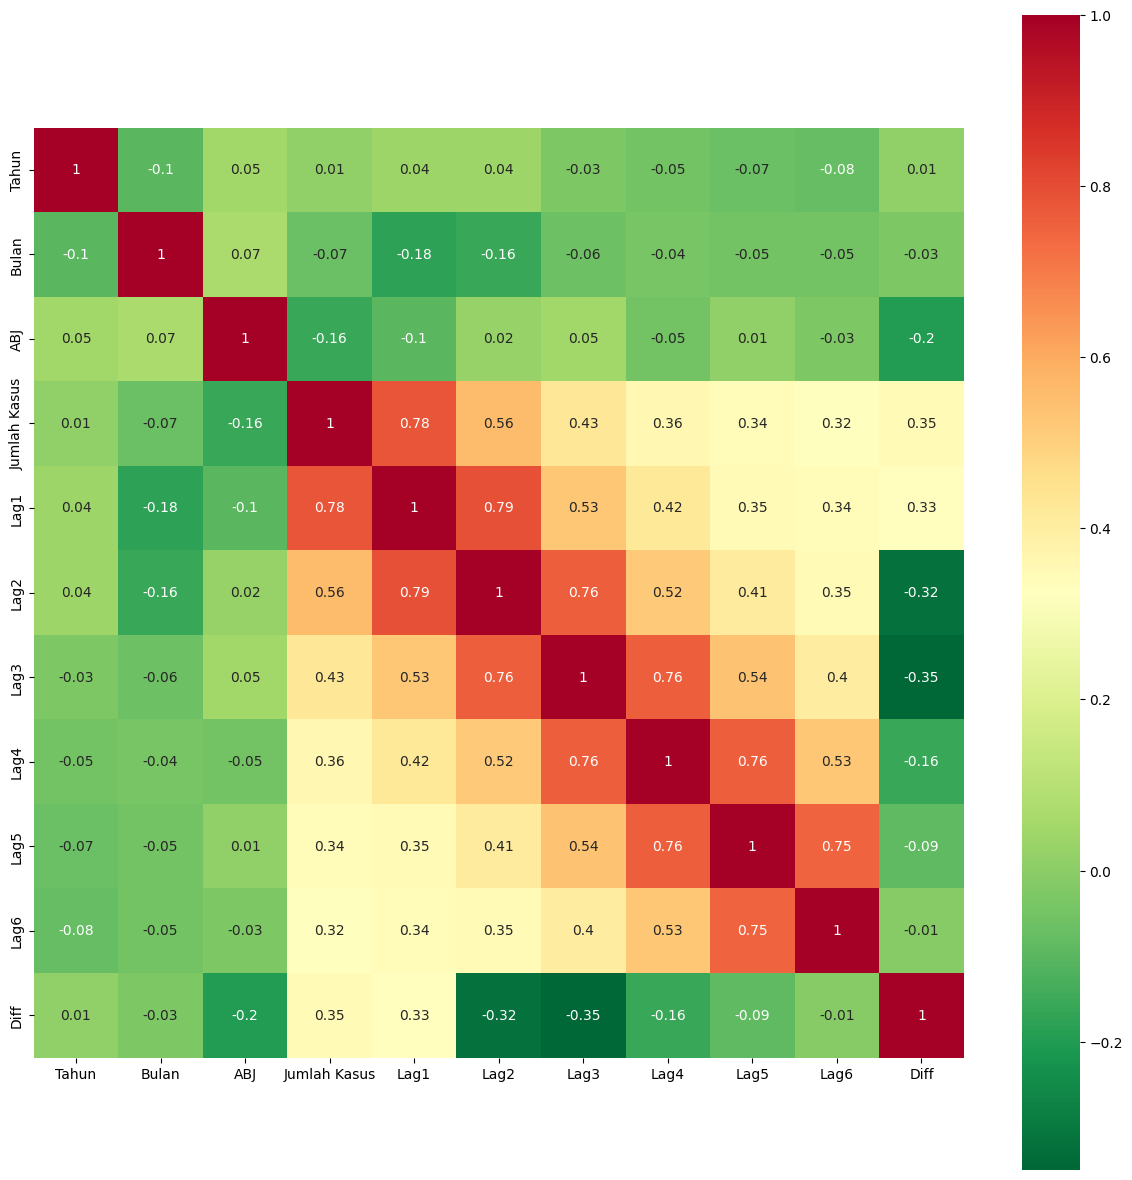

In [244]:

#correlation heatmap
correlation = df.corr(numeric_only=True)
plt.subplots(figsize = (15, 15))
sns.heatmap(correlation.round(2),
            annot = True,
            vmax = 1,
            square = True,
            cmap = 'RdYlGn_r')
plt.show()

PENGHAPUSAN FITUR YANG BERNILAI KONSTAN

In [245]:
#Penghapusan Fitur yang Bernilai Konstan

df = df.loc[:,df.apply(pd.Series.nunique) != 1]

In [246]:
df

,Tahun,Bulan,ABJ,Jumlah Kasus,Lag1,Lag2,Lag3,Lag4,Lag5,Lag6,Diff
No,,,,,,,,,,,
7,2017,7,0.8813,52,33.0,35.0,85.0,61.0,68.0,40.0,-2.0
8,2017,8,0.8696,46,52.0,33.0,35.0,85.0,61.0,68.0,19.0
9,2017,9,0.8947,40,46.0,52.0,33.0,35.0,85.0,61.0,-6.0
10,2017,10,0.8840,41,40.0,46.0,52.0,33.0,35.0,85.0,-6.0
11,2017,11,0.8804,50,41.0,40.0,46.0,52.0,33.0,35.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...
92,2024,8,0.8696,47,49.0,52.0,47.0,36.0,34.0,40.0,-3.0
93,2024,9,0.8947,44,47.0,49.0,52.0,47.0,36.0,34.0,-2.0
94,2024,10,0.8840,56,44.0,47.0,49.0,52.0,47.0,36.0,-3.0


PENGHAPUSAN FITUR BERKORELASI TINGGI

In [247]:
#find and remove correlated features
def correlation(dataset, threshold):
    col_corr = set() #set of all the names of correlated columns
    corr_matrix = dataset.corr()
    for i in range(len(corr_matrix.columns)):
      for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > threshold: #we are interested in absolute coeff value
          colname = corr_matrix.columns[i] #getting the name of column
          col_corr.add(colname)
    return col_corr

In [248]:
data_tanpa_fitur = df.drop('Jumlah Kasus',axis=1)

In [249]:
corr_features = correlation(data_tanpa_fitur, 0.8)
print('correlated features: ', len(set(corr_features)) )
print(corr_features)

#remove correlated features
df.drop(labels=corr_features, axis=1, inplace=True)

correlated features:  0
set()


In [250]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 90 entries, 7 to 96
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Tahun         90 non-null     int64  
 1   Bulan         90 non-null     int64  
 2   ABJ           90 non-null     float64
 3   Jumlah Kasus  90 non-null     int64  
 4   Lag1          90 non-null     float64
 5   Lag2          90 non-null     float64
 6   Lag3          90 non-null     float64
 7   Lag4          90 non-null     float64
 8   Lag5          90 non-null     float64
 9   Lag6          90 non-null     float64
 10  Diff          90 non-null     float64
dtypes: float64(8), int64(3)
memory usage: 8.4 KB


In [251]:
df.describe()

,Tahun,Bulan,ABJ,Jumlah Kasus,Lag1,Lag2,Lag3,Lag4,Lag5,Lag6,Diff
count,90.000000,90.000000,90.000000,90.000000,90.000000,90.000000,90.000000,90.000000,90.000000,90.000000,90.000000
mean,2020.733333,6.700000,0.885439,43.411111,43.366667,43.155556,43.477778,43.666667,43.900000,43.800000,0.211111
std,2.186784,3.465561,0.013886,19.084610,19.104356,19.090507,19.548975,19.636014,19.800153,19.796833,12.395627
min,2017.000000,1.000000,0.838500,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,-35.000000
25%,2019.000000,4.000000,0.877975,29.250000,29.250000,29.250000,29.250000,29.250000,29.250000,29.250000,-7.000000
50%,2021.000000,7.000000,0.888550,43.000000,43.000000,42.000000,42.000000,42.000000,42.000000,41.500000,0.500000
75%,2023.000000,10.000000,0.894700,55.750000,55.750000,55.750000,55.750000,56.750000,57.000000,57.000000,7.750000
max,2024.000000,12.000000,0.916800,94.000000,94.000000,94.000000,94.000000,94.000000,94.000000,94.000000,31.000000


CEK KEMBALI KORELASI

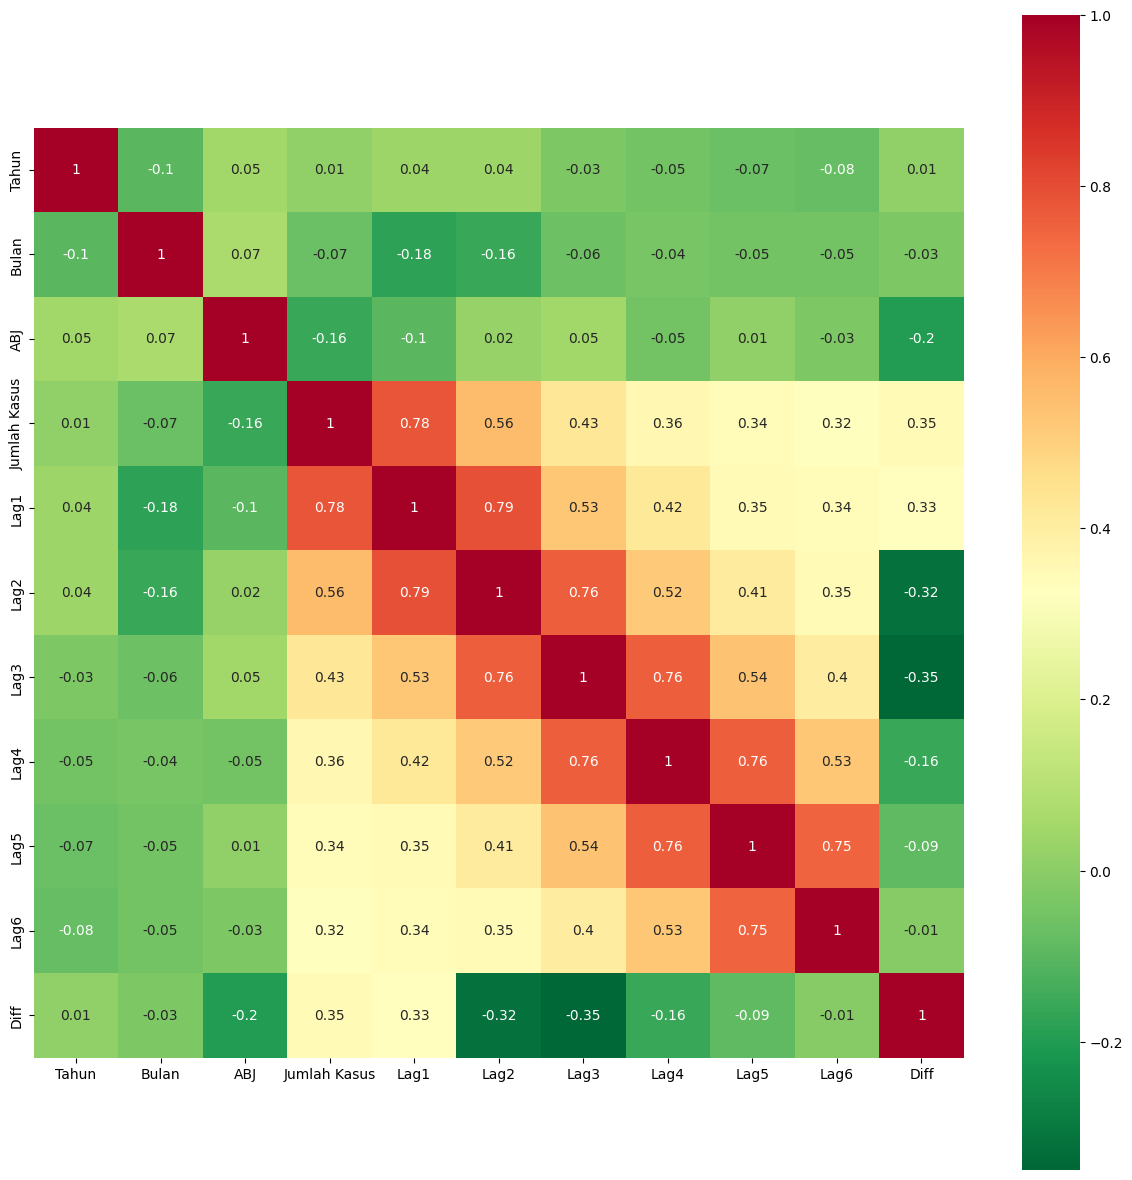

In [252]:
#correlation heatmap
correlation = df.corr()
plt.subplots(figsize = (15, 15))
sns.heatmap(correlation.round(2),
            annot = True,
            vmax = 1,
            square = True,
            cmap = 'RdYlGn_r')
plt.show()

UNIT 7

Persiapan Data

SPLIT DATA

In [253]:
# Pastikan data sudah terurut waktu
df = df.sort_values(by=['Tahun', 'Bulan']).reset_index(drop=True)

X = df.drop(['Jumlah Kasus', 'Tahun', 'Bulan'], axis=1)
y = df['Jumlah Kasus']

test_size = 12
split_index = len(X) - test_size

X_train = X.iloc[:split_index]
y_train = y.iloc[:split_index]

X_test  = X.iloc[split_index:]
y_test  = y.iloc[split_index:]


In [254]:
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.ensemble import RandomForestRegressor

tscv = TimeSeriesSplit(n_splits=3)

param_grid = {
    'bootstrap': [True, False],
    'n_estimators': [200, 300],
    'max_depth': [3, 5],
    'min_samples_split': [3, 5],
    'min_samples_leaf': [3, 5, 7],
    'max_features': ['sqrt']
}

rf = RandomForestRegressor(random_state=42)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best Hyperparameter:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)


Fitting 3 folds for each of 48 candidates, totalling 144 fits
Best Hyperparameter: {'bootstrap': True, 'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'min_samples_split': 3, 'n_estimators': 200}
Best Score: -21.01092902662654


In [255]:
y_pred = grid_search.best_estimator_.predict(X_test)

In [256]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

y_test = np.array(y_test)
y_pred = np.array(y_pred)

def calculate_mape(y_true, y_pred):
    mask = y_true != 0
    if np.sum(mask) == 0:
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)
mape = calculate_mape(y_test, y_pred)

print("--- HASIL EVALUASI MODEL ---")
print(f"R-Squared (R2) : {r2:.4f}")
print(f"RMSE           : {rmse:.4f}")
print(f"MAE            : {mae:.4f}")
print(f"MAPE           : {mape:.2f}%")


--- HASIL EVALUASI MODEL ---
R-Squared (R2) : 0.1202
RMSE           : 6.5261
MAE            : 4.7095
MAPE           : 10.46%


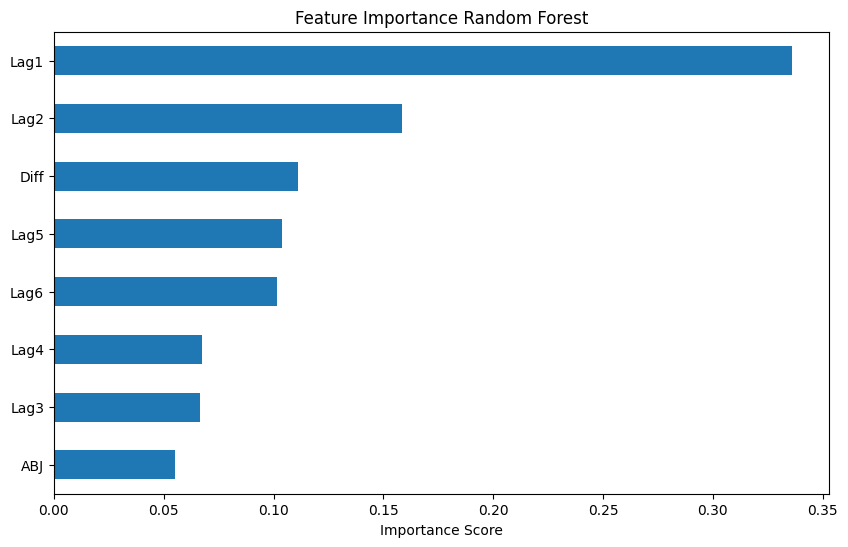

In [257]:
import pandas as pd
import matplotlib.pyplot as plt

best_model = grid_search.best_estimator_

importances = best_model.feature_importances_
feature_names = X_train.columns

feat_importances = pd.Series(importances, index=feature_names)\
                    .sort_values(ascending=True)

plt.figure(figsize=(10,6))
feat_importances.plot(kind='barh')
plt.title('Feature Importance Random Forest')
plt.xlabel('Importance Score')
plt.show()


In [258]:
# =============================
# 3️⃣ Buat DataFrame hasil prediksi vs aktual untuk data testing
# =============================
df_hasil_lengkap = pd.DataFrame({
    'Tahun': df.iloc[split_index:]['Tahun'].values,
    'Bulan': df.iloc[split_index:]['Bulan'].values,
    'Data Aktual': y_test,
    'Data Prediksi': y_pred
})

# Tambahkan kolom selisih / error
df_hasil_lengkap['Selisih (Error)'] = abs(df_hasil_lengkap['Data Aktual'] - df_hasil_lengkap['Data Prediksi'])

# Opsional: tambahkan kolom persentase error
df_hasil_lengkap['Persentase Error (%)'] = df_hasil_lengkap['Selisih (Error)'] / df_hasil_lengkap['Data Aktual'].replace(0, np.nan) * 100

# =============================
# 4️⃣ Tampilkan hasil
# =============================
print("--- PERBANDINGAN DATA AKTUAL VS PREDIKSI ---")
print(df_hasil_lengkap.head(50))

--- PERBANDINGAN DATA AKTUAL VS PREDIKSI ---
    Tahun  Bulan  Data Aktual  Data Prediksi  Selisih (Error)  \
0    2024      1           49      42.686835         6.313165   
1    2024      2           40      41.049664         1.049664   
2    2024      3           34      35.056347         1.056347   
3    2024      4           36      34.388518         1.611482   
4    2024      5           47      38.187923         8.812077   
5    2024      6           52      45.984180         6.015820   
6    2024      7           49      50.164494         1.164494   
7    2024      8           47      47.084051         0.084051   
8    2024      9           44      41.945430         2.054570   
9    2024     10           56      45.885836        10.114164   
10   2024     11           54      56.859880         2.859880   
11   2024     12           37      52.378664        15.378664   

    Persentase Error (%)  
0              12.884011  
1               2.624160  
2               3.106902  
3

In [259]:
import joblib
os.makedirs(os.path.dirname(MODEL_SAVE_PATH), exist_ok=True)
joblib.dump(best_model, MODEL_SAVE_PATH)

os.makedirs(os.path.dirname(RESULT_SAVE_PATH), exist_ok=True)
df_hasil_lengkap.to_csv(RESULT_SAVE_PATH, index=False)

os.makedirs(os.path.dirname(CLEANED_SAVE_PATH), exist_ok=True)
df.to_csv(CLEANED_SAVE_PATH, index=False)

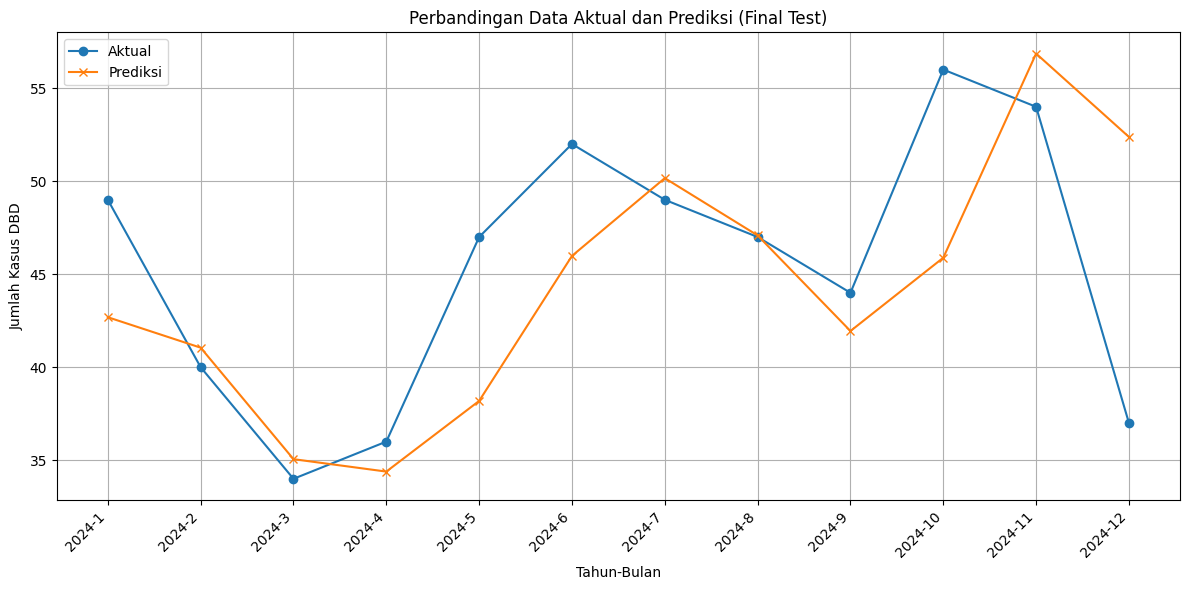

In [260]:
import matplotlib.pyplot as plt
import numpy as np

time_labels = (
    df_hasil_lengkap[['Tahun', 'Bulan']]
    .astype(str)
    .agg('-'.join, axis=1)
)

actuals_plot = df_hasil_lengkap['Data Aktual'].values
predictions_plot = df_hasil_lengkap['Data Prediksi'].values

plt.figure(figsize=(12,6))
plt.plot(time_labels, actuals_plot, label='Aktual', marker='o')
plt.plot(time_labels, predictions_plot, label='Prediksi', marker='x')

plt.title('Perbandingan Data Aktual dan Prediksi (Final Test)')
plt.xlabel('Tahun-Bulan')
plt.ylabel('Jumlah Kasus DBD')
plt.xticks(rotation=45, ha='right')

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()